<a href="https://colab.research.google.com/github/opeyemijanet/Credit_risk_portfolio_analysis/blob/main/Credit_Risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
df = pd.read_csv("/content/accepted_2007_to_2018Q4.csv")

/tmp/ipykernel_242/4022128123.py:1: DtypeWarning: Columns (19,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/accepted_2007_to_2018Q4.csv")


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168318 entries, 0 to 168317
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), object(36)
memory usage: 193.9+ MB


In [24]:
df.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,1.683180e+05,0.0,168318.000000,168318.000000,168318.000000,168318.000000,168318.000000,1.683180e+05,168316.000000,168318.000000,...,1220.0,1220.000000,1220.0,1220.000000,969.000000,1220.000000,1220.000000,5012.000000,5012.000000,5012.000000
mean,6.330487e+07,NaN,15250.366122,15250.366122,15242.032606,12.322041,440.375774,7.865105e+04,19.230325,0.344782,...,3.0,127.489295,3.0,14.313115,375.234675,10124.431131,187.755393,5010.906836,47.117253,13.506983
std,3.365734e+06,NaN,8657.359149,8657.359149,8652.544482,4.221537,247.084961,8.386013e+04,9.252218,0.912858,...,0.0,103.148544,0.0,9.749546,300.754441,6363.918364,182.938365,3531.689561,5.740415,7.477589
min,5.670500e+04,NaN,1000.000000,1000.000000,900.000000,5.320000,14.770000,0.000000e+00,0.000000,0.000000,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.020000,138.000000,20.000000,0.000000
25%,6.089446e+07,NaN,8400.000000,8400.000000,8400.000000,9.170000,260.850000,4.800000e+04,12.600000,0.000000,...,3.0,47.197500,3.0,7.000000,140.100000,4800.922500,45.075000,2196.152500,45.000000,8.000000
50%,6.340671e+07,NaN,14000.000000,14000.000000,14000.000000,12.050000,382.645000,6.600000e+04,18.700000,0.000000,...,3.0,99.230000,3.0,15.000000,293.520000,9049.015000,134.670000,4357.500000,45.000000,14.000000
75%,6.580189e+07,NaN,20000.000000,20000.000000,20000.000000,14.650000,579.880000,9.450000e+04,25.500000,0.000000,...,3.0,175.890000,3.0,23.000000,518.670000,14489.902500,277.442500,7000.000000,50.000000,18.000000
max,6.861706e+07,NaN,35000.000000,35000.000000,35000.000000,28.990000,1445.460000,9.000000e+06,999.000000,30.000000,...,3.0,638.130000,3.0,30.000000,1914.390000,29401.040000,927.790000,26242.500000,97.660000,65.000000


In [25]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [26]:
df.shape

(168318, 151)

In [27]:
df.isnull().sum()

,0
id,0
member_id,168318
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
...,...
settlement_status,163306
settlement_date,163306
settlement_amount,163306
settlement_percentage,163306


In [28]:
cols = ["loan_amnt"
"term"
"int_rate"
"grade"
"sub_grade"
"annual_inc"
"dti"
"emp_length"
"home_ownership"
"purpose"
"loan_status"
"delinq_2yrs"
"revol_util"
"open_acc"
"pub_rec"]

In [29]:
cols = [
    "loan_amnt",
    "term",
    "int_rate",
    "grade",
    "sub_grade",
    "annual_inc",
    "dti",
    "emp_length",
    "home_ownership",
    "purpose",
    "loan_status",
    "delinq_2yrs",
    "revol_util",
    "open_acc",
    "pub_rec"
]
loan_df = df[cols].copy()

In [30]:
loan_df.head()

,loan_amnt,term,int_rate,grade,sub_grade,annual_inc,dti,emp_length,home_ownership,purpose,loan_status,delinq_2yrs,revol_util,open_acc,pub_rec
0,3600.0,36 months,13.99,C,C4,55000.0,5.91,10+ years,MORTGAGE,debt_consolidation,Fully Paid,0.0,29.7,7.0,0.0
1,24700.0,36 months,11.99,C,C1,65000.0,16.06,10+ years,MORTGAGE,small_business,Fully Paid,1.0,19.2,22.0,0.0
2,20000.0,60 months,10.78,B,B4,63000.0,10.78,10+ years,MORTGAGE,home_improvement,Fully Paid,0.0,56.2,6.0,0.0
3,35000.0,60 months,14.85,C,C5,110000.0,17.06,10+ years,MORTGAGE,debt_consolidation,Current,0.0,11.6,13.0,0.0
4,10400.0,60 months,22.45,F,F1,104433.0,25.37,3 years,MORTGAGE,major_purchase,Fully Paid,1.0,64.5,12.0,0.0


In [31]:
loan_df.isna().sum()

,0
loan_amnt,0
term,0
int_rate,0
grade,0
sub_grade,0
annual_inc,0
dti,2
emp_length,10050
home_ownership,0
purpose,0


In [32]:
loan_df["emp_length"].unique()

array(['10+ years', '3 years', '4 years', '6 years', '1 year', '7 years',
       '8 years', '5 years', '2 years', '9 years', '< 1 year', nan],
      dtype=object)

In [34]:
loan_df["emp_length"] = pd.to_numeric(loan_df["emp_length"], errors = "coerce")

In [55]:
loan_df["emp_length"]=loan_df["emp_length"].fillna(loan_df["emp_length"].median())

In [36]:
#verify cleaning
loan_df["emp_length"].unique()

array([10. ,  3. ,  4. ,  6. ,  1. ,  7. ,  8. ,  5. ,  2. ,  9. ,  0.5])

In [37]:
loan_df.head()

,loan_amnt,term,int_rate,grade,sub_grade,annual_inc,dti,emp_length,home_ownership,purpose,loan_status,delinq_2yrs,revol_util,open_acc,pub_rec
0,3600.0,36 months,13.99,C,C4,55000.0,5.91,10.0,MORTGAGE,debt_consolidation,Fully Paid,0.0,29.7,7.0,0.0
1,24700.0,36 months,11.99,C,C1,65000.0,16.06,10.0,MORTGAGE,small_business,Fully Paid,1.0,19.2,22.0,0.0
2,20000.0,60 months,10.78,B,B4,63000.0,10.78,10.0,MORTGAGE,home_improvement,Fully Paid,0.0,56.2,6.0,0.0
3,35000.0,60 months,14.85,C,C5,110000.0,17.06,10.0,MORTGAGE,debt_consolidation,Current,0.0,11.6,13.0,0.0
4,10400.0,60 months,22.45,F,F1,104433.0,25.37,3.0,MORTGAGE,major_purchase,Fully Paid,1.0,64.5,12.0,0.0


Text(0, 0.5, 'Count')

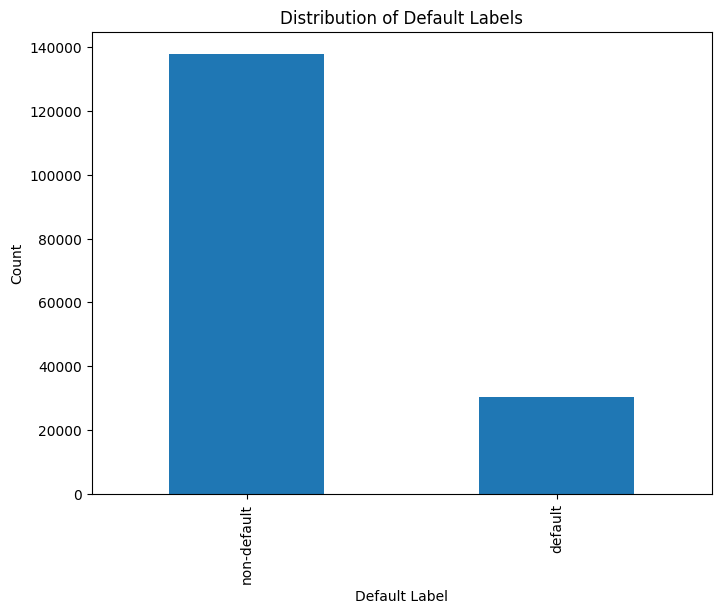

In [60]:
#create binary risk categories
loan_df["loan_status"].unique()
loan_df['default'] = loan_df["loan_status"].isin([
    "Charged Off",
    "Late (31-120 days)",
    "Late (16-30 days)"]).astype(int)

#verify
loan_df['default'].value_counts()

#create default labels
loan_df["default_label"] = loan_df['default'].map({1: "default", 0: "non-default"})

#visualize distribution
plt.figure(figsize=(8,6))
loan_df["default_label"].value_counts().plot(kind="bar")
plt.title("Distribution of Default Labels")
plt.xlabel("Default Label")
plt.ylabel("Count")

<Axes: >

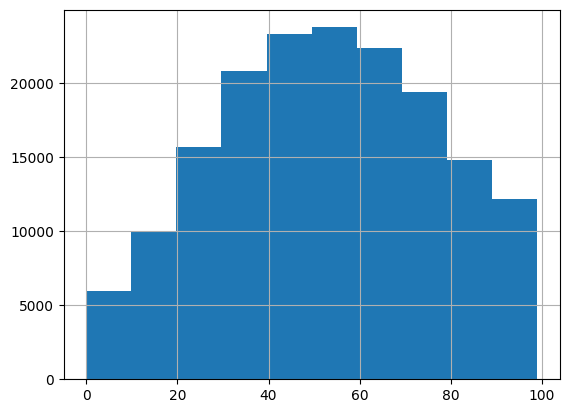

In [58]:
#issue2-clean revolving credit utilization rate
loan_df["revol_util"].unique()
#convert to numeric
loan_df["revol_util"] = pd.to_numeric(loan_df["revol_util"], errors='coerce')
loan_df["revol_util"]=loan_df["revol_util"].fillna(loan_df['revol_util'].median())
#cap extreme values
loan_df["revol_util"] = loan_df["revol_util"].clip(upper=loan_df["revol_util"].quantile(0.99))
loan_df["revol_util"].max()
loan_df["revol_util"].hist()

In [76]:
#issue3:clean debt to income ratio
loan_df["dti"]=loan_df["dti"].fillna(loan_df["dti"].median())

In [64]:
loan_df.isna().sum()

,0
loan_amnt,0
term,0
int_rate,0
grade,0
sub_grade,0
annual_inc,0
dti,0
emp_length,0
home_ownership,0
purpose,0


**Data Cleaning**

Before conducting the analysis, the dataset was cleaned to ensure consistency, accuracy, and suitability for credit risk analysis. The cleaning process addressed missing values, inconsistent data formats, and extreme outliers.

**Handling Missing Values**

Some variables contained missing observations, including employment length (emp_length), revolving credit utilization (revol_util), and debt-to-income ratio (dti). Missing values in these variables were imputed using the median, which is more robust than the mean for financial data that may contain skewed distributions or outliers.

**Standardizing Employment Length**

The emp_length variable originally contained text values such as “10+ years”, “3 years”, and “< 1 year”. These values were cleaned and converted into numeric representations of employment length in years to allow quantitative analysis.

**Revolving Credit Utilization**

The revol_util variable represents the proportion of available revolving credit currently used by the borrower. Since the values were recorded as percentages, the percentage symbols were removed and the column was converted into numeric format to facilitate analysis.

**Handling Outliers**

Extreme values in the revolving utilization variable were capped at the 99th percentile. This technique reduces the influence of unusually large values while preserving the overall distribution of the data.

**Creating the Default Indicator**

A binary default indicator was created from the loan status variable. Loans classified as “Charged Off” or “Default” were labeled as defaulted, while all other loan outcomes were treated as non-default. This variable serves as the target variable for credit risk analysis.



EXPLORATORY DATA ANALYSIS

In [68]:
#calculate portfolio default rate
default_rate = loan_df['default'].mean()
print(f"portfolio default_rate: {round(default_rate*100, 2)}%")

portfolio default_rate: 18.05%


<Axes: xlabel='grade'>

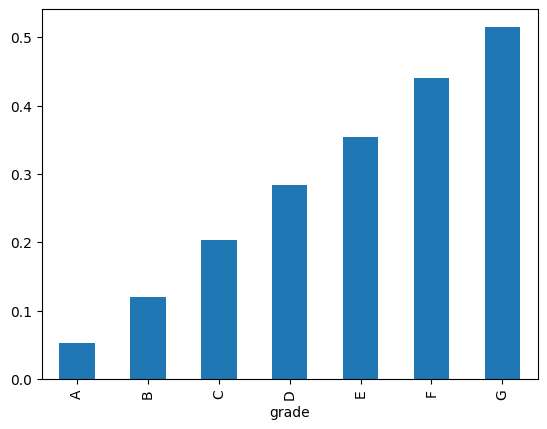

In [71]:
loan_df.groupby("grade")["default"].mean().plot(kind = 'bar')

Loan grade represents the lender’s assessment of borrower credit risk. As expected, default rates increase steadily as credit grade deteriorates from A (lowest risk) to G (highest risk). This confirms that the grading system effectively captures borrower credit quality.

/tmp/ipykernel_242/1561736612.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_df.groupby('income_groups')['default'].mean().plot(kind = "bar")


Text(0, 0.5, 'Default Rate')

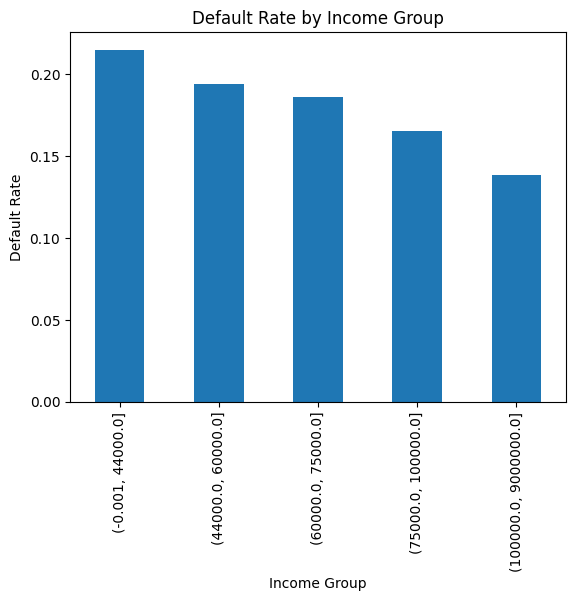

In [74]:
#default rate by income
#create income groups
loan_df['income_groups'] = pd.qcut(loan_df["annual_inc"], 5)
loan_df.groupby('income_groups')['default'].mean().plot(kind = "bar")
plt.title("Default Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Default Rate")

Borrowers in lower income brackets tend to exhibit higher default rates compared to higher income borrowers, suggesting income plays an important role in repayment ability.

/tmp/ipykernel_242/2907240571.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_df.groupby("dti_group")["default"].mean().plot(kind="bar")


Text(0, 0.5, 'Default Rate')

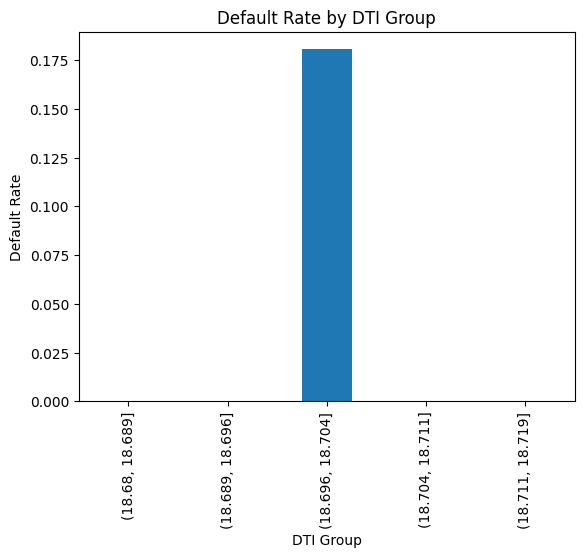

In [79]:
#default rate by debt to income ratio
loan_df["dti_group"] = pd.cut(loan_df["dti"], bins=5, include_lowest=True)

loan_df.groupby("dti_group")["default"].mean().plot(kind="bar")
plt.title("Default Rate by DTI Group")
plt.xlabel("DTI Group")
plt.ylabel("Default Rate")

<Axes: xlabel='purpose'>

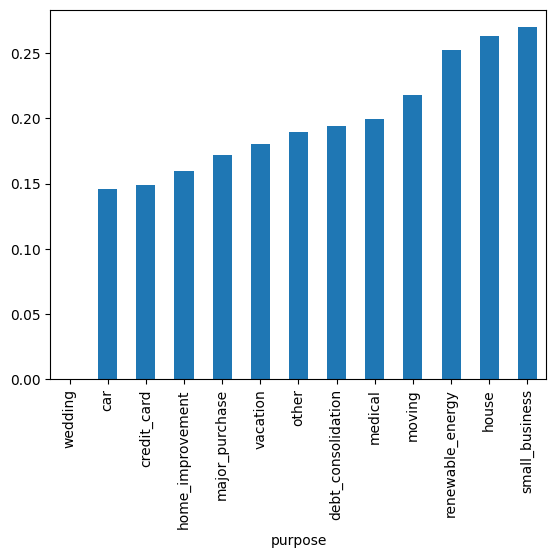

In [80]:
#default rate by loan purpose
loan_df.groupby("purpose")["default"].mean().sort_values().plot(kind="bar")

Certain loan purposes exhibit higher default rates, suggesting that the type of borrowing activity may influence repayment outcomes.

/tmp/ipykernel_242/1281519621.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_df.groupby("util_group")["default"].mean().plot(kind="bar")


<Axes: xlabel='util_group'>

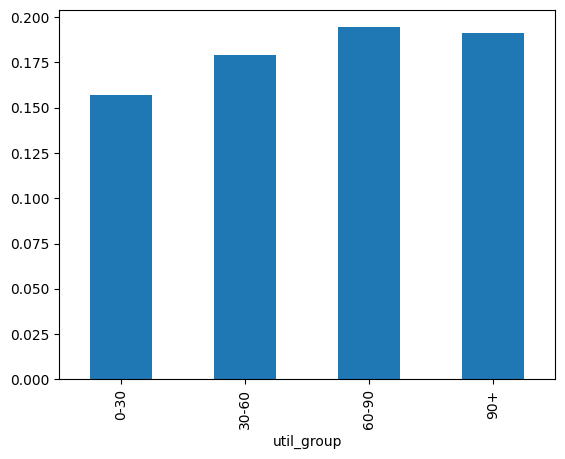

In [81]:
#default rate bt revolving credit
loan_df["util_group"] = pd.cut(
    loan_df["revol_util"],
    bins=[0,30,60,90,150],
    labels=["0-30","30-60","60-90","90+"]
)
loan_df.groupby("util_group")["default"].mean().plot(kind="bar")

Default risk increases with higher credit utilization. Borrowers utilizing a large portion of their available credit tend to show significantly higher default rates.

/tmp/ipykernel_242/3292459254.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  risk_matrix = loan_df.pivot_table(


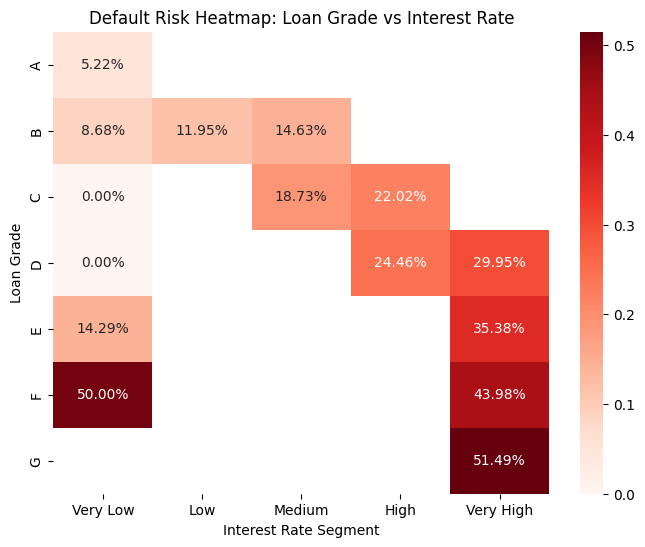

In [89]:
loan_df["int_rate"].dtype
#create interest rate buckets
loan_df["rate_group"] = pd.qcut(
    loan_df["int_rate"],
    5,
    labels=["Very Low","Low","Medium","High","Very High"]
)

grade_order = ["A","B","C","D","E","F","G"]

loan_df["grade"] = pd.Categorical(
    loan_df["grade"],
    categories=grade_order,
    ordered=True
)
#calculate default rate by segment

risk_matrix = loan_df.pivot_table(
    values="default",
    index="grade",
    columns="rate_group",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    risk_matrix,
    annot=True,
    fmt=".2%",
    cmap="Reds"
)

plt.title("Default Risk Heatmap: Loan Grade vs Interest Rate")
plt.xlabel("Interest Rate Segment")
plt.ylabel("Loan Grade")

plt.show()

Default risk increases significantly as borrower credit grade deteriorates and as interest rates rise. The highest risk segments are concentrated among lower credit grades combined with very high interest rates. In particular, Grade G loans with very high interest rates show default rates exceeding 50%, indicating substantial credit risk exposure in this segment.